In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from config import SimConfig
from src.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker

from src.plants.fc_only_plant import FuelCellOnlyPlant
from src.solvers.sdp_baseline import BaselineSDPSolver
from src.controllers.constant import ConstantControl
from src.controllers.threshold import ThresholdControl
from src.controllers.stochastic import StochasticControl
from src.plotting import plot_dynamic_history, plot_cost_comparison, plot_benchmarker_results

config = SimConfig()
fleet_data = load_and_cache_entire_fleet(config)

# Initialize benchmarker, excluding corrupted or unrepresentative data
exclude_days = [] # Adjust this list as needed based on data quality
benchmarker = VoyageBenchmarker(fleet_data, config, exclude_days)

Beginning memory staging of all 14 fleet files into RAM...
 -> Day 01 successfully cached in RAM.
 -> Day 02 successfully cached in RAM.
 -> Day 03 successfully cached in RAM.
 -> Day 04 successfully cached in RAM.
 -> Day 05 successfully cached in RAM.
 -> Day 06 successfully cached in RAM.
 -> Day 07 successfully cached in RAM.
 -> Day 08 successfully cached in RAM.
 -> Day 09 successfully cached in RAM.
 -> Day 10 successfully cached in RAM.
 -> Day 11 successfully cached in RAM.
 -> Day 12 successfully cached in RAM.
 -> Day 13 successfully cached in RAM.
 -> Day 14 successfully cached in RAM.

All 14 operational days securely held in RAM. Disk I/O locked.


In [3]:
# We wrap instantiations in functions so the benchmarker can spin up fresh 
# plants for every cross-validation day, preventing state-bleeding.

def build_constant(cfg, mc, horizon):
    return ConstantControl(cfg), FuelCellOnlyPlant(cfg)

def build_threshold(cfg, mc, horizon):
    return ThresholdControl(cfg, horizon, sigma=0.5), FuelCellOnlyPlant(cfg)

def build_sdp(cfg, mc, horizon):
    solver = BaselineSDPSolver(cfg, mc)
    policy = solver.compute_policy_matrix(horizon)
    ctrl = StochasticControl(mc['levels'], cfg.n_vals, policy)
    return ctrl, FuelCellOnlyPlant(cfg)

approaches = {
    "Constant Baseline": build_constant,
    "Threshold Heuristic": build_threshold,
    "Full SDP": build_sdp
}

In [ ]:
print("--- APPROACH A: HAND-PICKED EVALUATION ---")
# Manually choose training block and test validation target
train_days = [4, 5, 6, 7, 8, 9, 10]
test_day = 14
df_manual = benchmarker.compare_approaches(approaches, train_days, test_day)
display(df_manual)

plot_cost_comparison

--- APPROACH A: HAND-PICKED EVALUATION ---


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€],Computation Time [s]
Constant Baseline,9895.481995,9895.481995,0.00,0.0,0.0,0.166601
Threshold Heuristic,6691.257282,6616.257282,75.00,0.0,0.0,0.164521
Full SDP,6509.970126,6453.720126,56.25,0.0,0.0,0.177538



--- APPROACH B: LEAVE-ONE-OUT (Full SDP) ---


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€],Computation Time [s]
Day 1,4384.646148,4384.646148,0.000000,0.0,0.0,0.159327
Day 2,4146.998808,4146.998808,0.000000,0.0,0.0,0.160772
Day 3,7552.170682,7495.920682,56.250000,0.0,0.0,0.167963
Day 4,23582.535491,23582.535491,0.000000,0.0,0.0,0.167656
Day 5,16799.619090,16799.619090,0.000000,0.0,0.0,0.171020
Day 6,17661.440553,17661.440553,0.000000,0.0,0.0,0.260142
Day 7,18129.282932,18129.282932,0.000000,0.0,0.0,0.248747
Day 8,17551.007107,17551.007107,0.000000,0.0,0.0,0.246802
Day 9,21617.925044,21617.925044,0.000000,0.0,0.0,0.165743
Day 10,19502.764007,19502.764007,0.000000,0.0,0.0,0.160716


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€],Computation Time [s]
Day 1,2826.151835,2788.651835,37.50,0.0,0.0,0.162885
Day 2,2795.784789,2795.784789,0.00,0.0,0.0,0.165692
Day 3,7786.286257,7748.786257,37.50,0.0,0.0,0.156555
Day 4,8502.251051,8483.501051,18.75,0.0,0.0,0.162951
Day 5,6584.979326,6528.729326,56.25,0.0,0.0,0.163654
Day 6,6776.163545,6719.913545,56.25,0.0,0.0,0.242498
Day 7,7001.250417,6888.750417,112.50,0.0,0.0,0.235141
Day 8,6837.296203,6706.046203,131.25,0.0,0.0,0.216751
Day 9,7984.291328,7946.791328,37.50,0.0,0.0,0.225972
Day 10,7476.823124,7345.573124,131.25,0.0,0.0,0.235729


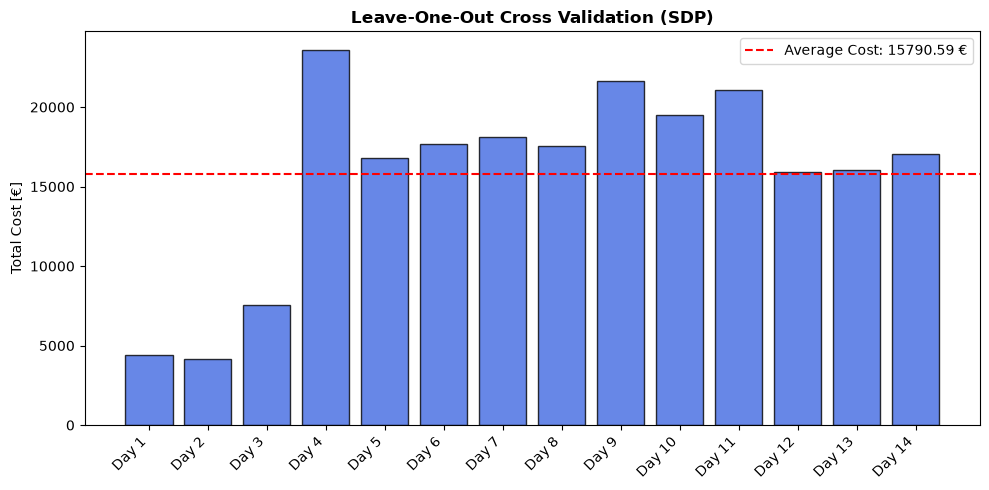

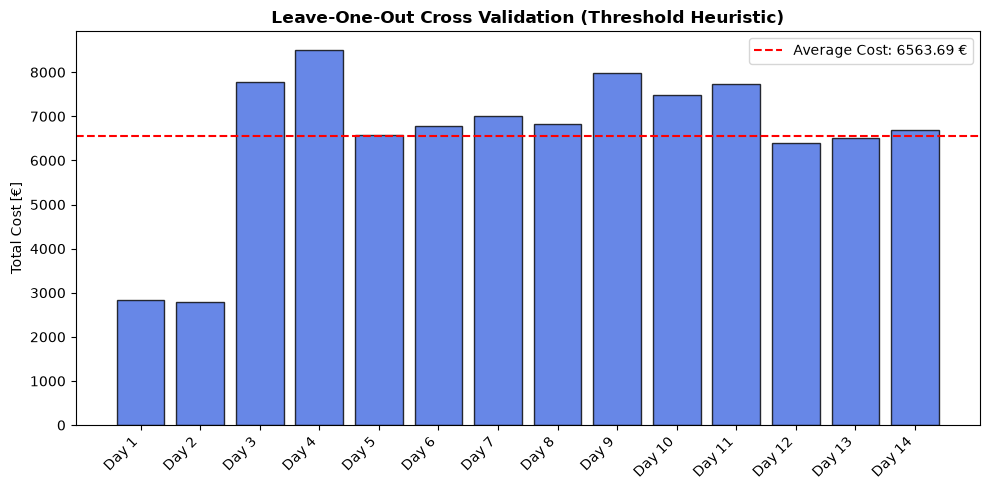

In [5]:
print("\n--- APPROACH B: LEAVE-ONE-OUT (Full SDP) ---")

# Systematically validate against every single viable day in the dataset
df_loo_sdp = benchmarker.run_leave_one_out(approaches["Full SDP"])
display(df_loo_sdp)

df_loo_thresh = benchmarker.run_leave_one_out(approaches["Threshold Heuristic"])
display(df_loo_thresh)


# Visualize the day-to-day volatility
plot_benchmarker_results(df_loo_sdp, title="Leave-One-Out Cross Validation (SDP)", plot_type='bar')
plot_benchmarker_results(df_loo_thresh, title="Leave-One-Out Cross Validation (Threshold Heuristic)", plot_type='bar')


--- APPROACH C: FORWARD CHAINING (Full SDP) ---


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€],Computation Time [s]
Train 1-1 -> Test 2,2320.641499,2264.391499,56.250000,0.0,0.0,0.188175
Train 1-2 -> Test 3,7552.170682,7495.920682,56.250000,0.0,0.0,0.209478
Train 1-3 -> Test 4,23582.535491,23582.535491,0.000000,0.0,0.0,0.225314
Train 1-4 -> Test 5,16799.619090,16799.619090,0.000000,0.0,0.0,0.179602
Train 1-5 -> Test 6,6735.501000,6679.251000,56.250000,0.0,0.0,0.188105
Train 1-6 -> Test 7,18129.282932,18129.282932,0.000000,0.0,0.0,0.174848
Train 1-7 -> Test 8,17551.007107,17551.007107,0.000000,0.0,0.0,0.215279
Train 1-8 -> Test 9,7963.844510,7907.594510,56.250000,0.0,0.0,0.177556
Train 1-9 -> Test 10,19502.764007,19502.764007,0.000000,0.0,0.0,0.174244
Train 1-10 -> Test 11,21083.743257,21083.743257,0.000000,0.0,0.0,0.190926


,Total Cost [€],Operating Cost [€],Switching Cost [€],Transient Cost [€],Battery Cost [€],Computation Time [s]
Train 1-1 -> Test 2,2795.784789,2795.784789,0.000000,0.0,0.0,0.194211
Train 1-2 -> Test 3,7786.286257,7748.786257,37.500000,0.0,0.0,0.163951
Train 1-3 -> Test 4,8502.251051,8483.501051,18.750000,0.0,0.0,0.176044
Train 1-4 -> Test 5,6584.979326,6528.729326,56.250000,0.0,0.0,0.166348
Train 1-5 -> Test 6,6776.163545,6719.913545,56.250000,0.0,0.0,0.236679
Train 1-6 -> Test 7,7001.250417,6888.750417,112.500000,0.0,0.0,0.203628
Train 1-7 -> Test 8,6837.296203,6706.046203,131.250000,0.0,0.0,0.162281
Train 1-8 -> Test 9,7984.291328,7946.791328,37.500000,0.0,0.0,0.159447
Train 1-9 -> Test 10,7476.823124,7345.573124,131.250000,0.0,0.0,0.183706
Train 1-10 -> Test 11,7735.452858,7716.702858,18.750000,0.0,0.0,0.233070


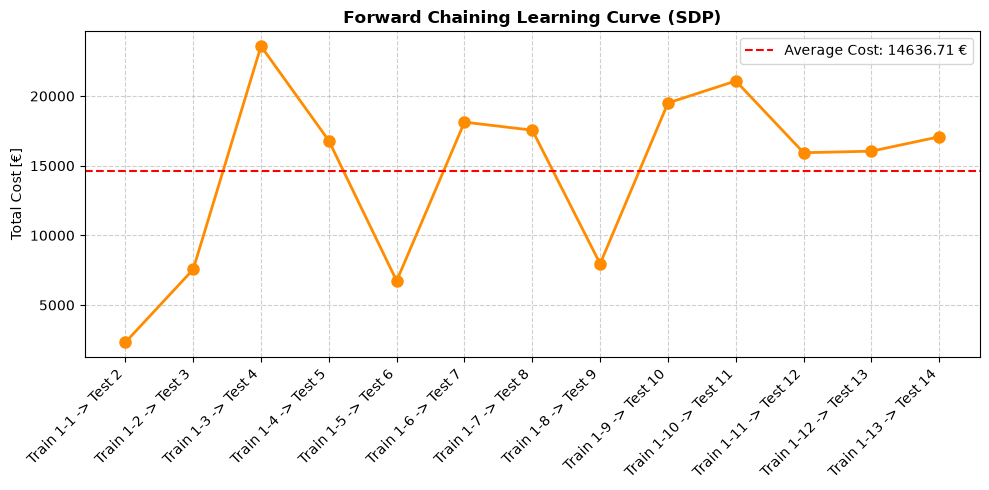

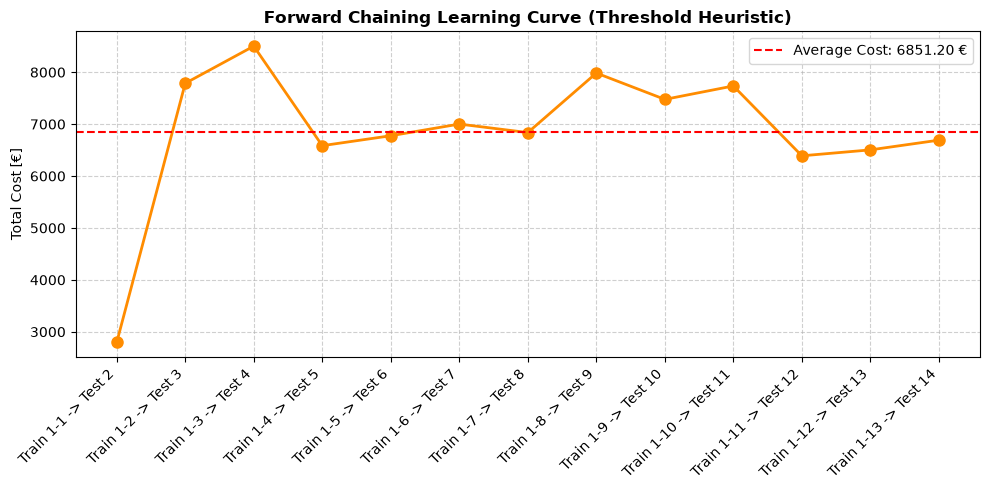

In [6]:

print("\n--- APPROACH C: FORWARD CHAINING (Full SDP) ---")
# Evaluate how the policy improves as the agent gathers chronological data
df_for_sdp = benchmarker.run_forward_chaining(approaches["Full SDP"])
display(df_for_sdp)

df_for_thresh = benchmarker.run_forward_chaining(approaches["Threshold Heuristic"])
display(df_for_thresh)


# Visualize the day-to-day volatility
plot_benchmarker_results(df_for_sdp, title="Forward Chaining Learning Curve (SDP)", plot_type='line')
plot_benchmarker_results(df_for_thresh, title="Forward Chaining Learning Curve (Threshold Heuristic)", plot_type='line')